Mounted the google drive to get the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing modules that is necessary for the project

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import pandas as pd
import os
from tensorflow.keras.utils import img_to_array, load_img
import json
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from skimage.draw import polygon
from concurrent.futures import ThreadPoolExecutor
from tensorflow.keras.layers import Dropout
from sklearn.metrics import precision_score, recall_score, confusion_matrix, f1_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from tensorflow.keras import layers, models
import albumentations as A


defining the image directory and annotation file path

In [ ]:

train_image_dir = '/content/drive/MyDrive/archive/train'
train_mask_path = '/content/drive/MyDrive/archive/train/_annotations.coco.json'
val_image_dir = '/content/drive/MyDrive/archive/valid'
val_mask_path = '/content/drive/MyDrive/archive/valid/_annotations.coco.json'
test_image_dir = '/content/drive/MyDrive/archive/test'
test_mask_path = '/content/drive/MyDrive/archive/test/_annotations.coco.json'


defining important parameters

In [ ]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
input_size = (128, 128, 3)

this code will display the images in each directory

Total number of image files in /content/drive/MyDrive/archive/train: 1502
Total number of image files in /content/drive/MyDrive/archive/valid: 429
Total number of image files in /content/drive/MyDrive/archive/test: 215


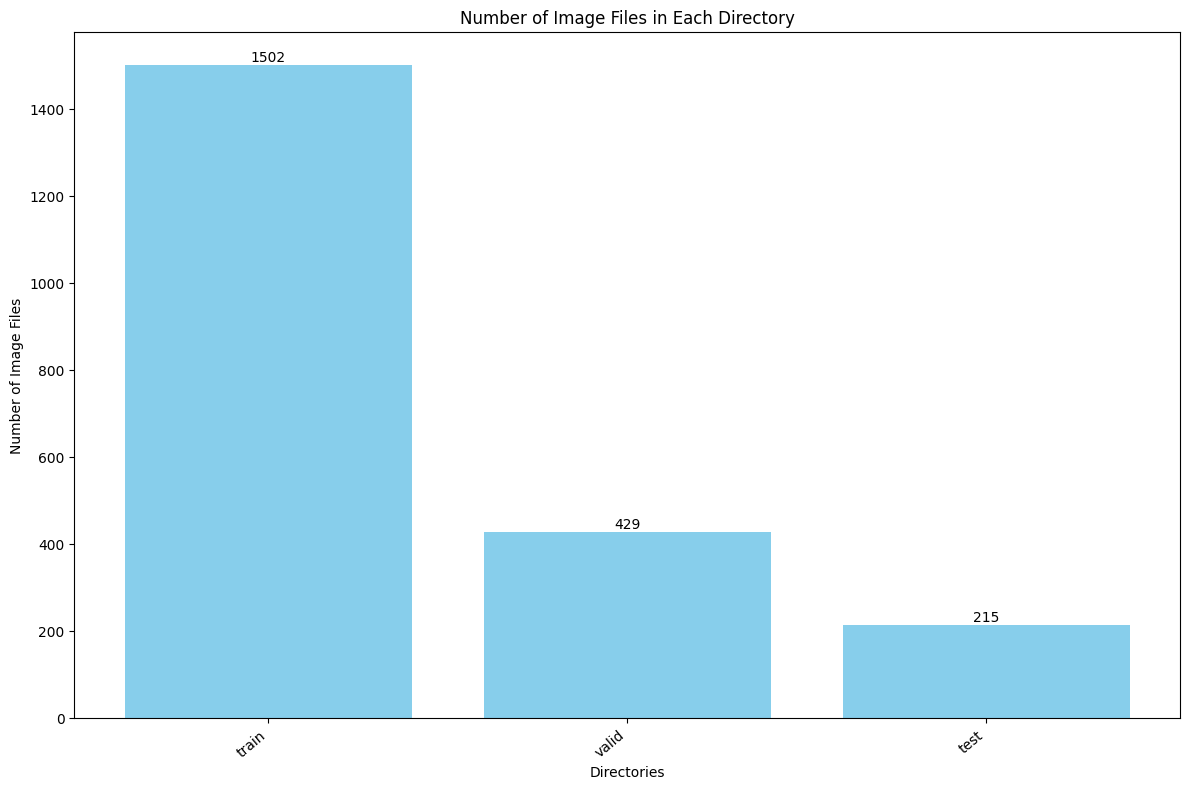

In [ ]:

# Function to count image files in a directory
def count_image_files(directory):
    # Supported image extensions
    image_extensions = ['.png', '.jpg', '.jpeg']

    # Dictionary to store count of each type
    image_count = {ext: 0 for ext in image_extensions}
    total_images = 0

    # Walk through directory
    for root, dirs, files in os.walk(directory):
        for file in files:
            # Get file extension
            extension = os.path.splitext(file)[1].lower()
            if extension in image_extensions:
                image_count[extension] += 1
                total_images += 1

    return total_images

# Function to plot the image counts
def plot_image_counts(image_counts, directory_names):
    plt.figure(figsize=(12, 8))
    bars = plt.bar(directory_names, image_counts, color='skyblue')
    plt.xlabel('Directories')
    plt.ylabel('Number of Image Files')
    plt.title('Number of Image Files in Each Directory')
    plt.xticks(rotation=40, ha='right')
    # Add counts above the bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, int(yval), ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

# List of directories
directories = [
    train_image_dir, val_image_dir, test_image_dir
]

# Get directory names from paths
directory_names = [os.path.basename(directory) for directory in directories]

# Count image files in each directory
image_counts = []
for directory in directories:
    image_count = count_image_files(directory)
    image_counts.append(image_count)
    print(f"Total number of image files in {directory}: {image_count}")

# Plot the results
plot_image_counts(image_counts, directory_names)


this code is to get the mask images from the original image

In [ ]:
def create_mask_from_annotations(annotations, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    for annotation in annotations:
        for seg in annotation['segmentation']:
            poly = np.array(seg).reshape((len(seg) // 2, 2))
            rr, cc = polygon(poly[:, 1], poly[:, 0], (height, width))
            mask[rr, cc] = 1
    return mask


def process_image(img_info, image_dir, coco):
    img_path = os.path.join(image_dir, img_info['file_name'])
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Unable to read image at {img_path}")
        return None, None

    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    img = img / 255.0

    ann_ids = coco.getAnnIds(imgIds=img_info['id'])
    annotations = coco.loadAnns(ann_ids)

    mask = create_mask_from_annotations(annotations, img_info['height'], img_info['width'])
    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
    mask = mask / 255.0

    mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
    mask = (mask > 0).astype(np.float32)

    return img, mask

def load_images_and_masks(image_dir, mask_path, img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    coco = COCO(mask_path)
    images = []
    masks = []

    img_ids = coco.getImgIds()
    img_infos = coco.loadImgs(img_ids)

    # Use ThreadPoolExecutor to process images in parallel
    with ThreadPoolExecutor() as executor:
        results = list(executor.map(lambda img_info: process_image(img_info, image_dir, coco), img_infos))

    for image, mask in results:
        if image is not None and mask is not None:
            images.append(image)
            masks.append(mask)

    images = np.array(images)
    masks = np.array(masks)
    masks = np.expand_dims(masks, axis=-1)  # Add channel dimension

    return images, masks



# Load annotations
train_image, train_mask = load_images_and_masks(train_image_dir, train_mask_path)
val_image, val_mask = load_images_and_masks(val_image_dir,val_mask_path)
test_image, test_mask = load_images_and_masks(test_image_dir, test_mask_path)

loading annotations into memory...
Done (t=1.25s)
creating index...
index created!
loading annotations into memory...
Done (t=0.97s)
creating index...
index created!
loading annotations into memory...
Done (t=0.93s)
creating index...
index created!


plotting the original image with the mask image

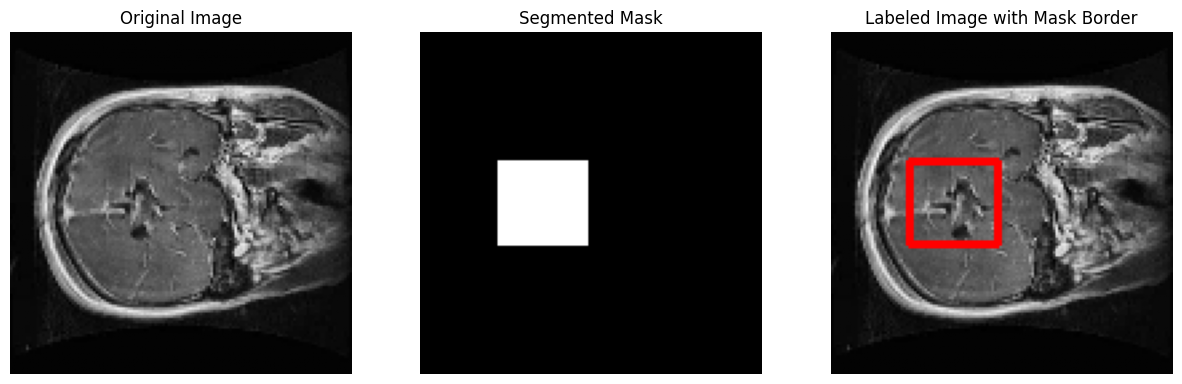

In [ ]:
def plot_image_mask_and_labeled(img, mask):
    # Ensure the mask has the correct shape: (height, width)
    if len(mask.shape) == 3 and mask.shape[2] == 1:  # If mask has shape (height, width, 1)
        mask = mask.squeeze(axis=-1)  # Convert to (height, width)

    # If the image is grayscale (2D), convert it to a 3D RGB image
    if len(img.shape) == 2 or img.shape[2] == 1:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    # Create a labeled image by overlaying the border of the mask onto the original image
    labeled_img = img.copy()

    # Find contours in the mask
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Draw contours on the image
    cv2.drawContours(labeled_img, contours, -1, (255, 0, 0), thickness=2)  # Red color, 2-pixel thickness

    plt.figure(figsize=(15, 5))

    # Plot the original image
    plt.subplot(1, 3, 1)
    plt.imshow(img)
    plt.title("Original Image")
    plt.axis('off')

    # Plot the mask
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Segmented Mask")
    plt.axis('off')

    # Plot the labeled image with the mask border
    plt.subplot(1, 3, 3)
    plt.imshow(labeled_img)
    plt.title("Labeled Image with Mask Border")
    plt.axis('off')

    plt.show()


# Sample usage:
sample_idx = 0  # Change index to plot different samples
plot_image_mask_and_labeled(train_image[sample_idx], train_mask[sample_idx])


**Defining the U-Net model and compile the model**

In [ ]:
# Define the U-Net model
def unet_model(input_size=(128, 128, 3)):
    inputs = Input(input_size)

    # Encoder
    convolution1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    convolution1 = Conv2D(64, (3, 3), activation='relu', padding='same')(convolution1)
    pooling1 = MaxPooling2D((2, 2))(convolution1)

    convolution2 = Conv2D(128, (3, 3), activation='relu', padding='same')(pooling1)
    convolution2 = Conv2D(128, (3, 3), activation='relu', padding='same')(convolution2)
    pooling2 = MaxPooling2D((2, 2))(convolution2)

    convolution3 = Conv2D(256, (3, 3), activation='relu', padding='same')(pooling2)
    convolution3 = Conv2D(256, (3, 3), activation='relu', padding='same')(convolution3)
    pooling3 = MaxPooling2D((2, 2))(convolution3)

    convolution4 = Conv2D(512, (3, 3), activation='relu', padding='same')(pooling3)
    convolution4 = Conv2D(512, (3, 3), activation='relu', padding='same')(convolution4)
    pooling4 = MaxPooling2D((2, 2))(convolution4)

    # Bottleneck
    convolution5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(pooling4)
    convolution5 = Dropout(0.5)(convolution5)  # Adding dropout
    convolution5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(convolution5)

    # Decoder
    upsample6 = UpSampling2D((2, 2))(convolution5)
    upsample6 = concatenate([upsample6, convolution4])
    convolution6 = Conv2D(512, (3, 3), activation='relu', padding='same')(upsample6)
    convolution6 = Conv2D(512, (3, 3), activation='relu', padding='same')(convolution6)

    upsample7 = UpSampling2D((2, 2))(convolution6)
    upsample7 = concatenate([upsample7, convolution3])
    convolution7 = Conv2D(256, (3, 3), activation='relu', padding='same')(upsample7)
    convolution7 = Conv2D(256, (3, 3), activation='relu', padding='same')(convolution7)

    upsample8 = UpSampling2D((2, 2))(convolution7)
    upsample8 = concatenate([upsample8, convolution2])
    convolution8 = Conv2D(128, (3, 3), activation='relu', padding='same')(upsample8)
    convolution8 = Conv2D(128, (3, 3), activation='relu', padding='same')(convolution8)

    upsample9 = UpSampling2D((2, 2))(convolution8)
    upsample9 = concatenate([upsample9, convolution1])
    convolution9 = Conv2D(64, (3, 3), activation='relu', padding='same')(upsample9)
    convolution9 = Conv2D(64, (3, 3), activation='relu', padding='same')(convolution9)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(convolution9)

    model = Model(inputs=[inputs], outputs=[outputs], name='UNet_Model')
    return model


In [ ]:
# Instantiate the model
UNETmodel = unet_model(input_size=input_size)

UNETmodel.summary()

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
UNETmodel.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])


Model: "UNet_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 128, 128, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 128, 128, 64)   │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 128, 128, 64)   │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 64, 64, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 64, 64, 128)    │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 32, 32, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 16, 16, 256)    │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 8, 8, 512)      │              0 │ conv2d_7[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 8, 8, 1024)     │              0 │ conv2d_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 8, 8, 1024)     │      9,438,208 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d             │ (None, 16, 16, 1024)   │              0 │ conv2d_9[0][0]         │
│ (UpSampling2D)            │                        │                │                        │
├──────────────────────

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('unet_best_model.keras', save_best_only=True)

Fitting the model with 30 epochs

In [ ]:
UNethistory = UNETmodel.fit(
    train_image, train_mask,
    validation_data=(val_image, val_mask),
    epochs=30,
    callbacks=[early_stopping, model_checkpoint]
)

Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.9601 - loss: 0.3973 - val_accuracy: 0.9633 - val_loss: 0.1260
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 75s 549ms/step - accuracy: 0.9625 - loss: 0.1161 - val_accuracy: 0.9633 - val_loss: 0.1100
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 43s 588ms/step - accuracy: 0.9627 - loss: 0.1084 - val_accuracy: 0.9633 - val_loss: 0.1083
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 26s 561ms/step - accuracy: 0.9632 - loss: 0.1053 - val_accuracy: 0.9633 - val_loss: 0.1036
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 41s 553ms/step - accuracy: 0.9633 - loss: 0.1006 - val_accuracy: 0.9633 - val_loss: 0.0998
Epoch 6/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 43s 599ms/step - accuracy: 0.9631 - loss: 0.0953 - val_accuracy: 0.9633 - val_loss: 0.0914
Epoch 7/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 40s 573ms/step - accuracy: 0.9632 - loss: 0.0904 - val_accuracy: 0.9633 - val_loss: 0.0846
Epoch 8/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 497ms/step - accuracy: 0.9657 - loss: 0.0814 - val_accura

Calculating test loss and test accuracy for U-Net model

In [ ]:
# evaluate on the test dataset
UNettest_loss, UNettest_accuracy = UNETmodel.evaluate(test_image, test_mask, verbose=1)
print(f"U-Net model Test Loss: {UNettest_loss}")
print(f"U-Net model Test Accuracy: {UNettest_accuracy}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.9800 - loss: 0.0553
U-Net model Test Loss: 0.05189976468682289
U-Net model Test Accuracy: 0.9807512164115906


Display the predicted output image

In [ ]:
def plot_masked_images(masks):

  # Function to display images
  def display_images(images, titles=None, cmap=None):
    nimg = len(images)
    plt.figure(figsize=(10, 10))
    for i in range(nimg):
        plt.subplot(1, nimg, i + 1)
        plt.imshow(images[i], cmap=cmap)
        if titles:
            plt.title(titles[i])
        plt.axis('off')
    plt.show()



  # Display some test images with their true and predicted masks
  num_of_images_to_display = 5
  indices = np.random.choice(len(test_image), num_of_images_to_display, replace=False)

  for i in indices:
    test_img = test_image[i]
    true_mask = test_mask[i].squeeze()
    predicted_mask = masks[i].squeeze()

    display_images(
        [test_img, true_mask, predicted_mask],
        titles=['Test Image', 'True Mask', 'Predicted Mask'],
        cmap='gray'
    )


In [ ]:
# Predict masks on the test set
UNetpredicted_masks = UNETmodel.predict(test_image)

# Threshold the predicted masks
UNetpredicted_masks = (UNetpredicted_masks > 0.5).astype(np.uint8)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 256ms/step


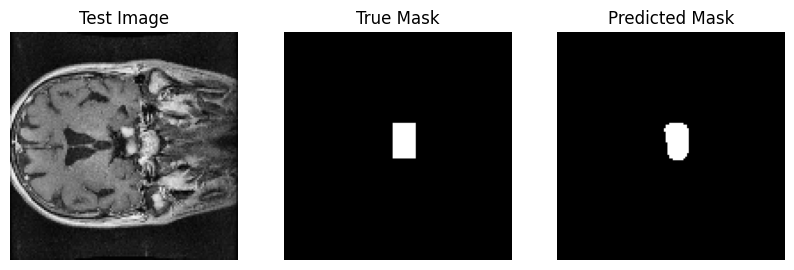

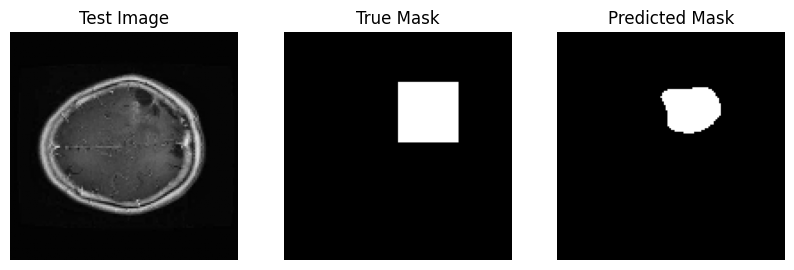

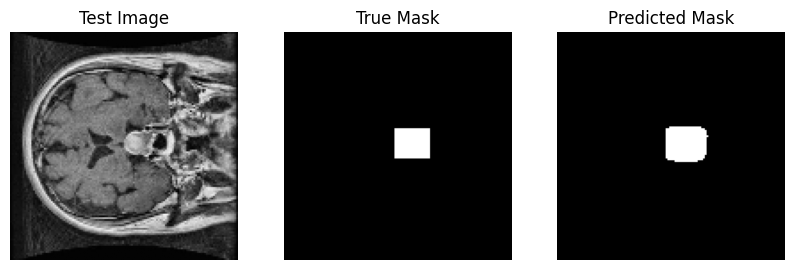

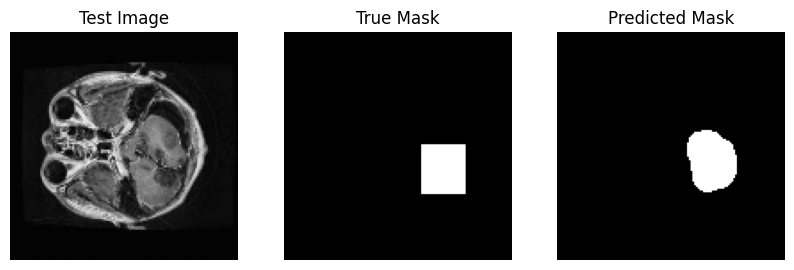

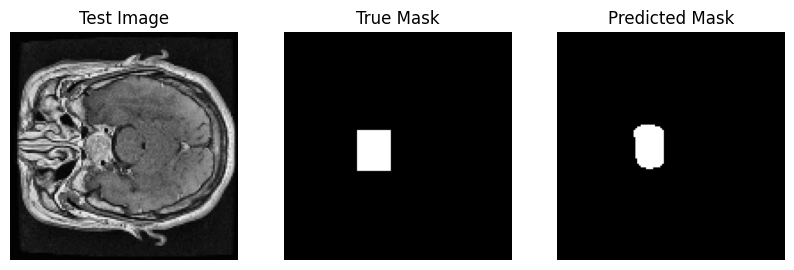

In [ ]:
plot_masked_images(UNetpredicted_masks)

plot the accuracy and loss graph

In [ ]:
def plot_accuracy_loss_graph(testHistory):
  #  Plot the loss graph
  plt.figure(figsize=(10, 6))

  # Plot training & validation loss values
  plt.subplot(1, 2, 1)
  plt.plot(testHistory.history['loss'], label='Train Loss')
  plt.plot(testHistory.history['val_loss'], label='Validation Loss')
  plt.title('Model Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(loc='upper right')

  #  Plot the accuracy graph
  # Plot training & validation accuracy values
  plt.subplot(1, 2, 2)
  plt.plot(testHistory.history['accuracy'], label='Train Accuracy')
  plt.plot(testHistory.history['val_accuracy'], label='Validation Accuracy')
  plt.title('Model Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend(loc='upper left')

  # Display the plots
  plt.tight_layout()
  plt.show()


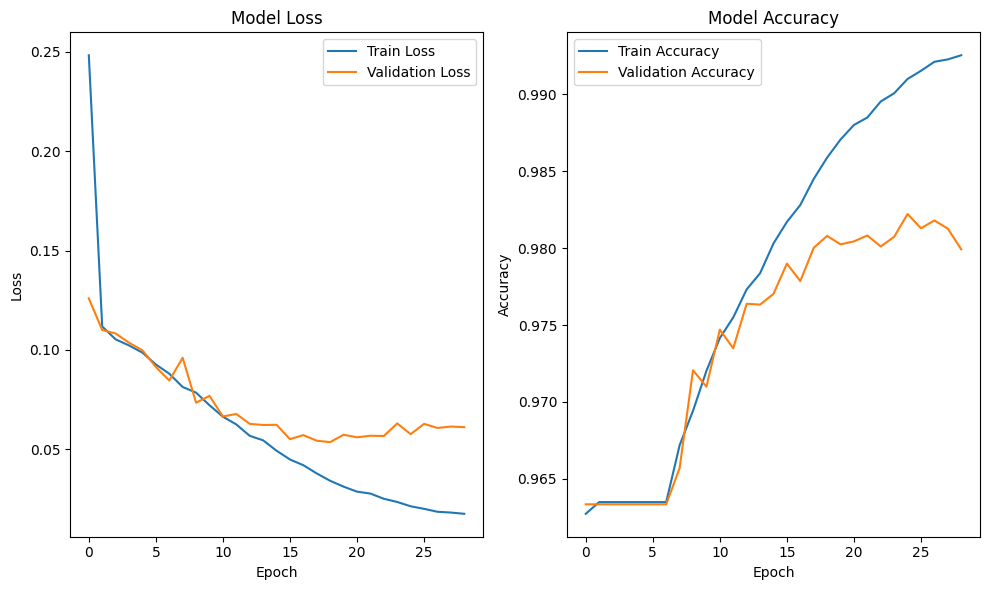

In [ ]:
plot_accuracy_loss_graph(UNethistory)

calculate the value of precision, recall and f1-score as well as plot confusion matrix graph

In [ ]:
image_label = "Test Image"
mask_label = "Mask"

def calculate_evaluation_matrix(masks):
  # Flatten the true masks
  y_true = test_mask.reshape(-1)  # Flatten to 1D array

  # Flatten the predicted masks and apply threshold
  y_pred = (masks > 0.5).astype(np.uint8).reshape(-1)  # Flatten to 1D array



  # Check if the shapes match
  if y_true.shape != y_pred.shape:
      raise ValueError(f"Shape mismatch: y_true has shape {y_true.shape}, but y_pred has shape {y_pred.shape}")

  # Compute the confusion matrix
  model_conf_matrix = confusion_matrix(y_true, y_pred)

  # Visualize the confusion matrix
  plt.figure(figsize=(8, 6))
  sns.heatmap(model_conf_matrix, annot=True, fmt='d', cmap='Blues',
              xticklabels=[f'Predicted {mask_label}', f'Predicted {image_label}'],
              yticklabels=[f'True {mask_label}', f'True {image_label}'])
  plt.xlabel('Predicted Masks')
  plt.ylabel('True Masks')
  plt.title('Confusion Matrix')
  plt.show()


  TN, FP, FN, TP = model_conf_matrix.ravel()


  precision = TP / (TP + FP)
  recall = TP / (TP + FN)
  f1 = f1_score(y_true, y_pred)

  print(f'Precision: {precision}')
  print(f'Recall: {recall}')
  print(f'F1 Score: {f1:.4f}')

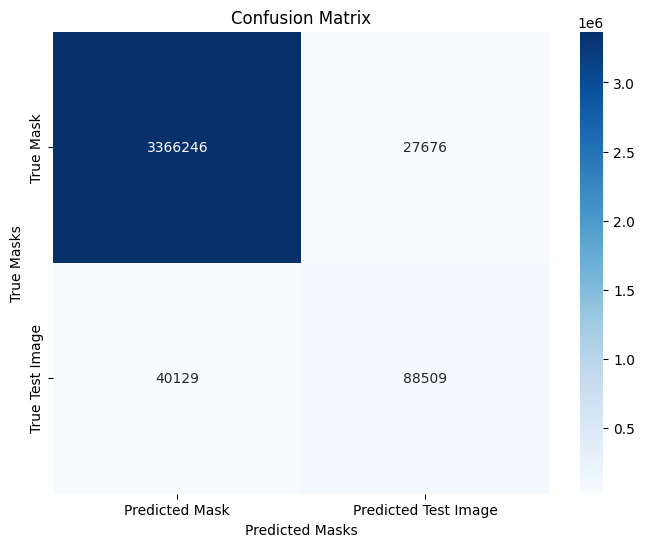

Precision: 0.7617936910960967
Recall: 0.6880470778463595
F1 Score: 0.7230


In [ ]:
calculate_evaluation_matrix(UNetpredicted_masks)

Defining the DeepLabv3+ model and compile the model

In [ ]:
def conv2d_block(x, filters, kernel_size=3, padding='same', activation='relu'):
    x = layers.Conv2D(filters, kernel_size, padding=padding)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    return x

def atrous_spatial_pyramid_pooling(x):
    # ASPP block
    b4 = layers.Conv2D(256, (1, 1), padding='same', activation='relu')(x)
    b4 = layers.BatchNormalization()(b4)

    b6 = layers.Conv2D(256, (3, 3), dilation_rate=(6, 6), padding='same', activation='relu')(x)
    b6 = layers.BatchNormalization()(b6)

    b12 = layers.Conv2D(256, (3, 3), dilation_rate=(12, 12), padding='same', activation='relu')(x)
    b12 = layers.BatchNormalization()(b12)

    b18 = layers.Conv2D(256, (3, 3), dilation_rate=(18, 18), padding='same', activation='relu')(x)
    b18 = layers.BatchNormalization()(b18)

    # Image pooling branch
    b_pool = layers.GlobalAveragePooling2D()(x)
    b_pool = layers.Reshape((1, 1, b_pool.shape[-1]))(b_pool)
    b_pool = layers.Conv2D(256, (1, 1), padding='same', activation='relu')(b_pool)
    b_pool = layers.BatchNormalization()(b_pool)
    b_pool = layers.UpSampling2D(size=(x.shape[1], x.shape[2]), interpolation='bilinear')(b_pool)

    # Concatenate all branches
    x = layers.Concatenate()([b4, b6, b12, b18, b_pool])
    x = layers.Conv2D(256, (1, 1), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x

def deeplabv3_model(input_shape, n_classes):
    inputs = tf.keras.Input(shape=input_shape)

    # Backbone: Xception
    backbone = tf.keras.applications.Xception(input_shape=input_shape, include_top=False, weights='imagenet')
    x = backbone(inputs, training=False)

    # ASPP
    x = atrous_spatial_pyramid_pooling(x)

    # Decoder: Upsampling to match input size
    x = layers.Conv2DTranspose(128, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    x = conv2d_block(x, 128)

    x = layers.Conv2DTranspose(64, (3, 3), strides=(2, 2), padding='same', activation='relu')(x)
    x = conv2d_block(x, 64)

    # Final upsampling to exact size
    x = layers.Conv2DTranspose(n_classes, (16, 16), strides=(8, 8), padding='same')(x)
    outputs = layers.Activation('sigmoid')(x)

    model = models.Model(inputs, outputs, name='DeepLabv3_model')
    return model

In [ ]:
DeepLmodel = deeplabv3_model((128, 128, 3), 1)
DeepLmodel.summary()

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "DeepLabv3_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ xception (Functional)     │ (None, 4, 4, 2048)     │     20,861,480 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 2048)           │              0 │ xception[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ reshape (Reshape)         │ (None, 1, 1, 2048)     │              0 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_27 (Conv2D)        │ (None, 1, 1, 256)      │        524,544 │ reshape[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_23 (Conv2D)        │ (None, 4, 4, 256)      │        524,544 │ xception[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_24 (Conv2D)        │ (None, 4, 4, 256)      │      4,718,848 │ xception[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_25 (Conv2D)        │ (None, 4, 4, 256)      │      4,718,848 │ xception[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_26 (Conv2D)        │ (None, 4, 4, 256)      │      4,718,848 │ xception[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_8     │ (None, 1, 1, 256)      │          1,024 │ conv2d_27[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 4, 4, 256)      │          1,024 │ conv2d_23[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_5     │ (None, 4, 4, 256)      │          1,024 │ conv2d_24[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_6     │ (None, 4, 4, 256)      │          1,024 │ conv2d_25[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_7     │ (None, 4, 4, 256)      │          1,024 │ conv2d_26[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d_4           │ (None, 4, 4, 256)      │              0 │ batch_normalization_8… │
│ (UpSampling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_4        

 Total params: 36,971,689 (141.04 MB)

 Trainable params: 36,913,705 (140.81 MB)

 Non-trainable params: 57,984 (226.50 KB)

In [ ]:
# Define custom loss function
def dice_coefficient(y_true, y_pred, smooth=1):
    y_truef = tf.keras.backend.flatten(y_true)
    y_predf = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_truef * y_predf)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_truef) + tf.keras.backend.sum(y_predf) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

In [ ]:
# Compile the model
DeepLmodel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=['accuracy', dice_coefficient]
)

In [ ]:

DeepLhistory = DeepLmodel.fit(
    train_image, train_mask,
    validation_data=(val_image, val_mask),
    batch_size=16,
    epochs=30,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('deeplabv3_plus_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 213s 1s/step - accuracy: 0.5332 - dice_coefficient: 0.0848 - loss: 0.9152 - val_accuracy: 0.8183 - val_dice_coefficient: 0.0959 - val_loss: 0.9041
Epoch 2/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 67s 552ms/step - accuracy: 0.7562 - dice_coefficient: 0.1345 - loss: 0.8655 - val_accuracy: 0.8879 - val_dice_coefficient: 0.1463 - val_loss: 0.8537
Epoch 3/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 80s 533ms/step - accuracy: 0.8491 - dice_coefficient: 0.1708 - loss: 0.8292 - val_accuracy: 0.9155 - val_dice_coefficient: 0.1962 - val_loss: 0.8038
Epoch 4/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 67s 377ms/step - accuracy: 0.9044 - dice_coefficient: 0.2170 - loss: 0.7830 - val_accuracy: 0.9481 - val_dice_coefficient: 0.2332 - val_loss: 0.7669
Epoch 5/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 54s 517ms/step - accuracy: 0.9454 - dice_coefficient: 0.2880 - loss: 0.7120 - val_accuracy: 0.9470 - val_dice_coefficient: 0.2826 - val_loss: 0.7176
Epoch 6/30
94/94 ━━━━━━━━━━━━━━━━━━━━ 81s 504ms/step - accuracy: 0.

In [ ]:
#test_image, test_mask = preprocess_data(test_image, test_mask, target_size=(IMG_HEIGHT, IMG_WIDTH))
DeepLtest_loss, DeepLtest_accuracy, DeepLdice_loss = DeepLmodel.evaluate(test_image, test_mask, verbose=1)
print(f"DeepLab Test Loss: {DeepLtest_loss}")
print(f"DeepLab Test Accuracy: {DeepLtest_accuracy}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9814 - dice_coefficient: 0.7341 - loss: 0.2652
DeepLab Test Loss: 0.2683032155036926
DeepLab Test Accuracy: 0.9820017218589783


In [ ]:
# Predict masks on the test set
DeepLpredicted_masks = DeepLmodel.predict(test_image)

# Apply a threshold to binarize the predicted masks
DeepLpredicted_masks = (DeepLpredicted_masks > 0.5).astype(np.uint8)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step


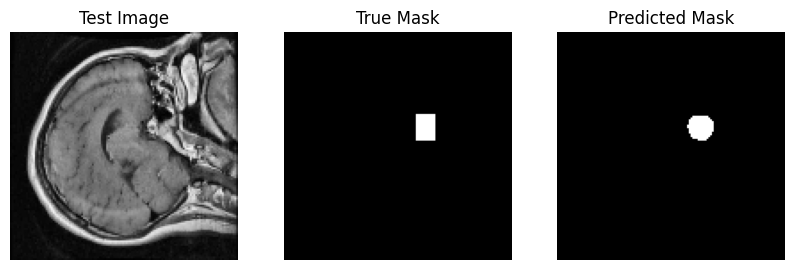

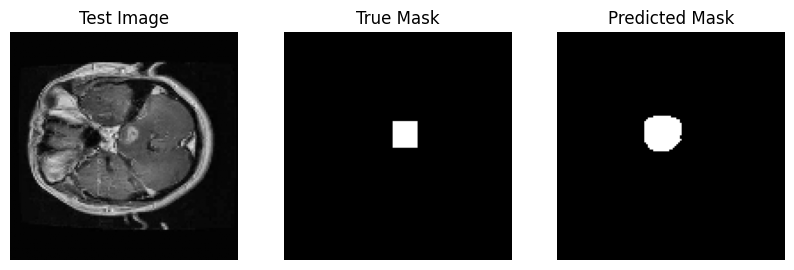

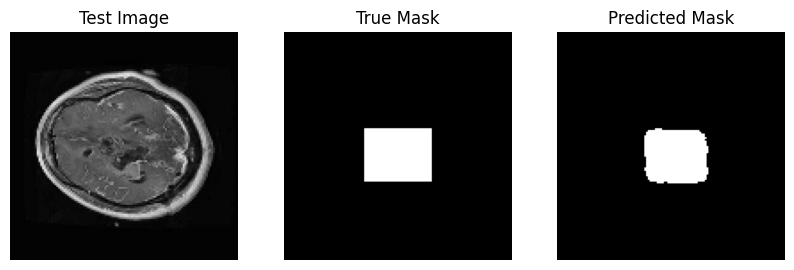

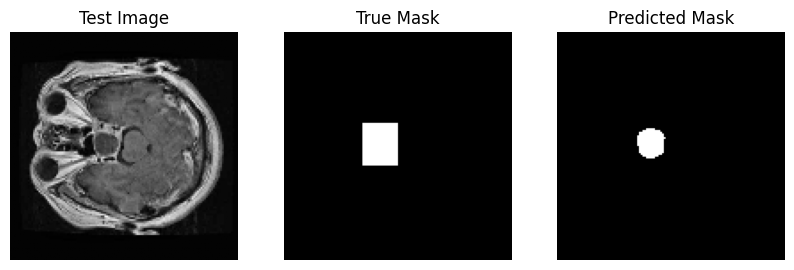

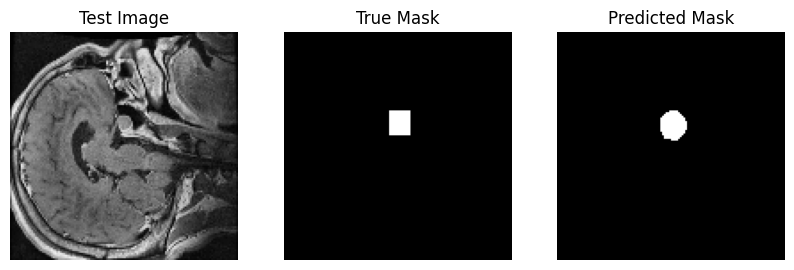

In [ ]:
plot_masked_images(DeepLpredicted_masks)

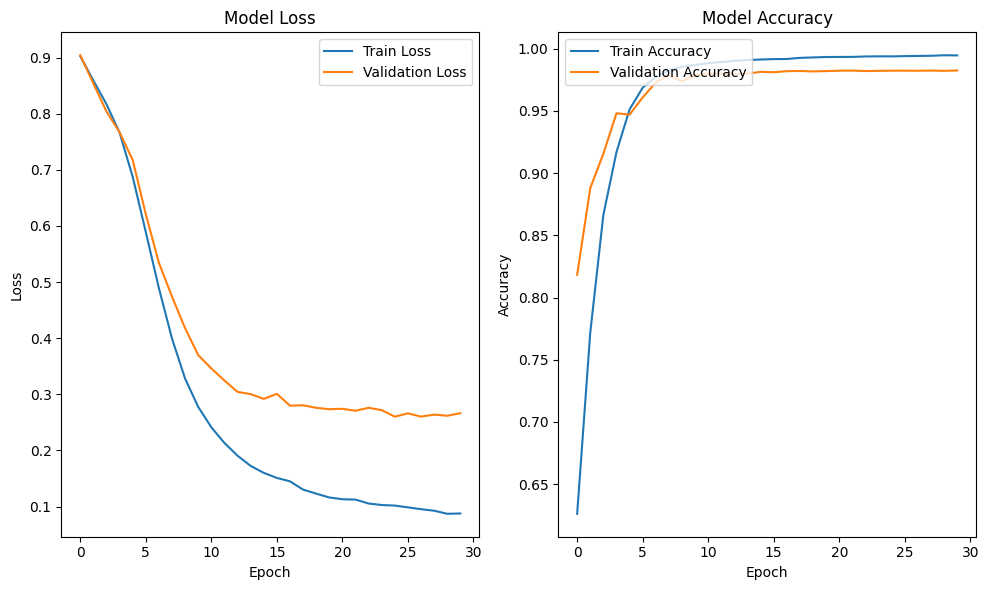

In [ ]:
plot_accuracy_loss_graph(DeepLhistory)

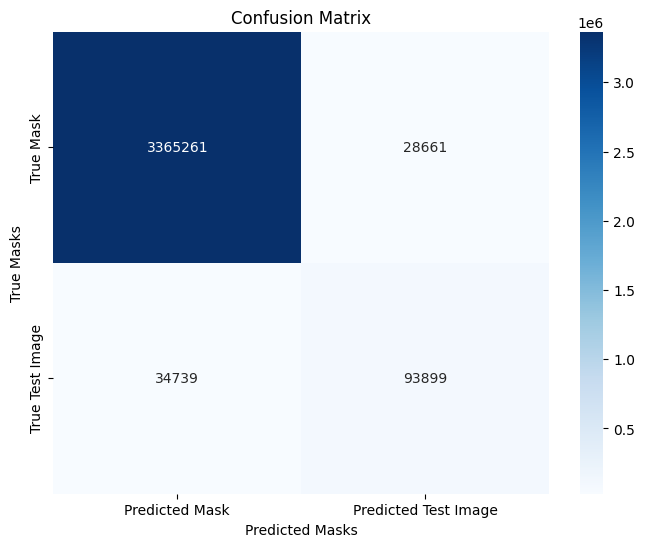

Precision: 0.7661471932114883
Recall: 0.7299476049067927
F1 Score: 0.7476


In [ ]:
calculate_evaluation_matrix(DeepLpredicted_masks)

Define the FCN model and compile the model

In [ ]:

def fcn_model(inputShape):
    inputs = layers.Input(shape=inputShape)

    # Encoder: Convolutional layers with pooling
    convolution1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
    convolution1 = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(convolution1)
    pooling1 = layers.MaxPooling2D((2, 2))(convolution1)  # 256x256

    convolution2 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(pooling1)
    convolution2 = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(convolution2)
    pooling2 = layers.MaxPooling2D((2, 2))(convolution2)  # 128x128

    convolution3 = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(pooling2)
    convolution3 = layers.Conv2D(256, (3, 3), padding='same', activation='relu')(convolution3)
    pooling3 = layers.MaxPooling2D((2, 2))(convolution3)  # 64x64

    convolution4 = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(pooling3)
    convolution4 = layers.Conv2D(512, (3, 3), padding='same', activation='relu')(convolution4)
    pooling4 = layers.MaxPooling2D((2, 2))(convolution4)  # 32x32

    convolution5 = layers.Conv2D(1024, (3, 3), padding='same', activation='relu')(pooling4)
    convolution5 = layers.Conv2D(1024, (3, 3), padding='same', activation='relu')(convolution5)  # 32x32

    # Upsampling and skip connections
    up6 = layers.Conv2DTranspose(512, (4, 4), strides=(2, 2), padding='same')(convolution5)  # 64x64
    up6 = layers.add([up6, convolution4])  # Combine with conv4 (64x64)

    up7 = layers.Conv2DTranspose(256, (4, 4), strides=(2, 2), padding='same')(up6)  # 128x128
    up7 = layers.add([up7, convolution3])  # Combine with conv3 (128x128)

    up8 = layers.Conv2DTranspose(128, (4, 4), strides=(2, 2), padding='same')(up7)  # 256x256
    up8 = layers.add([up8, convolution2])  # Combine with conv2 (256x256)

    up9 = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same')(up8)  # 512x512
    up9 = layers.add([up9, convolution1])  # Combine with conv1 (512x512)

    # Final output layer
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(up9)

    # Create model
    model = models.Model(inputs, outputs, name='fcn_model')
    return model

# Example usage
inputShape = (128, 128, 3)
FCNmodel = fcn_model(inputShape)
FCNmodel.summary()


Model: "fcn_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4             │ (None, 128, 128, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_41 (Conv2D)        │ (None, 128, 128, 64)   │          1,792 │ input_layer_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_42 (Conv2D)        │ (None, 128, 128, 64)   │         36,928 │ conv2d_41[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_8           │ (None, 64, 64, 64)     │              0 │ conv2d_42[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_43 (Conv2D)        │ (None, 64, 64, 128)    │         73,856 │ max_pooling2d_8[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_44 (Conv2D)        │ (None, 64, 64, 128)    │        147,584 │ conv2d_43[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_9           │ (None, 32, 32, 128)    │              0 │ conv2d_44[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_45 (Conv2D)        │ (None, 32, 32, 256)    │        295,168 │ max_pooling2d_9[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_46 (Conv2D)        │ (None, 32, 32, 256)    │        590,080 │ conv2d_45[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_10          │ (None, 16, 16, 256)    │              0 │ conv2d_46[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_47 (Conv2D)        │ (None, 16, 16, 512)    │      1,180,160 │ max_pooling2d_10[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_48 (Conv2D)        │ (None, 16, 16, 512)    │      2,359,808 │ conv2d_47[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_11          │ (None, 8, 8, 512)      │              0 │ conv2d_48[0][0]        │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_49 (Conv2D)        │ (None, 8, 8, 1024)     │      4,719,616 │ max_pooling2d_11[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_50 (Conv2D)        │ (None, 8, 8, 1024)     │      9,438,208 │ conv2d_49[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_transpose_4        │ (None, 16, 16, 512)    │      8,389,120 │ conv2d_50[0][0]        │
│ (Conv2DTranspose)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add_12 (Add)         

 Total params: 29,985,345 (114.39 MB)

 Trainable params: 29,985,345 (114.39 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
FCNmodel.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', dice_coefficient]
)

In [ ]:
len_train_image = len(train_image)

In [ ]:
FCNhistory = FCNmodel.fit(
    train_image, train_mask,
    steps_per_epoch= len_train_image // 16,
    validation_data=(val_image, val_mask),
    epochs=30,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        tf.keras.callbacks.ModelCheckpoint('FCN_best_model.keras', save_best_only=True)
    ]
)

Epoch 1/30
89/93 ━━━━━━━━━━━━━━━━━━━━ 1s 340ms/step - accuracy: 0.9621 - dice_coefficient: 0.0547 - loss: 0.3600

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


93/93 ━━━━━━━━━━━━━━━━━━━━ 82s 592ms/step - accuracy: 0.9621 - dice_coefficient: 0.0560 - loss: 0.3538 - val_accuracy: 0.9633 - val_dice_coefficient: 0.1433 - val_loss: 0.1148
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 32s 313ms/step - accuracy: 0.9637 - dice_coefficient: 0.1522 - loss: 0.1102 - val_accuracy: 0.9633 - val_dice_coefficient: 0.1438 - val_loss: 0.1130
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 36s 262ms/step - accuracy: 0.9636 - dice_coefficient: 0.1662 - loss: 0.1071 - val_accuracy: 0.9633 - val_dice_coefficient: 0.1617 - val_loss: 0.1079
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 51s 373ms/step - accuracy: 0.9631 - dice_coefficient: 0.1948 - loss: 0.1026 - val_accuracy: 0.9633 - val_dice_coefficient: 0.2080 - val_loss: 0.1010
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 33s 353ms/step - accuracy: 0.9652 - dice_coefficient: 0.2168 - loss: 0.0958 - val_accuracy: 0.9641 - val_dice_coefficient: 0.2355 - val_loss: 0.0967
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 36s 296ms/step - accuracy: 0.9652 - di

In [ ]:
#test_image, test_mask = preprocess_data(test_image, test_mask, target_size=(IMG_HEIGHT, IMG_WIDTH))
FCNtest_loss, FCNtest_accuracy, dice_loss = FCNmodel.evaluate(test_image, test_mask, verbose=1)
print(f"FCN model Test Loss: {FCNtest_loss}")
print(f"FCN model Test Accuracy: {FCNtest_accuracy}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9782 - dice_coefficient: 0.5985 - loss: 0.0556
FCN model Test Loss: 0.05350262671709061
FCN model Test Accuracy: 0.9787373542785645


In [ ]:
# Predict masks on the test set
FCNpredicted_masks = FCNmodel.predict(test_image)

FCNpredicted_masks = (FCNpredicted_masks > 0.5).astype(np.uint8)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step


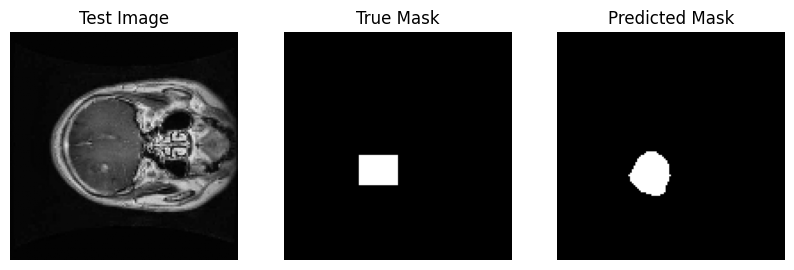

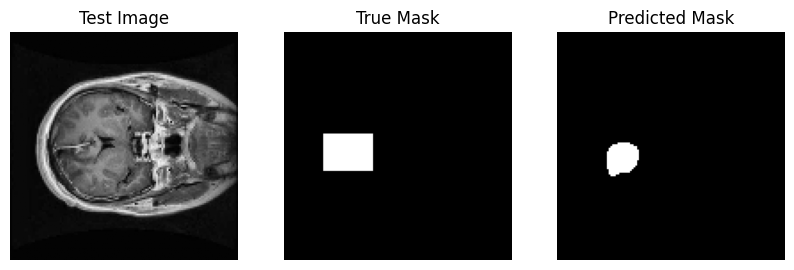

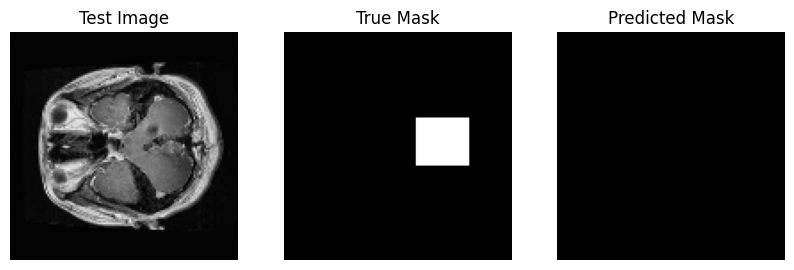

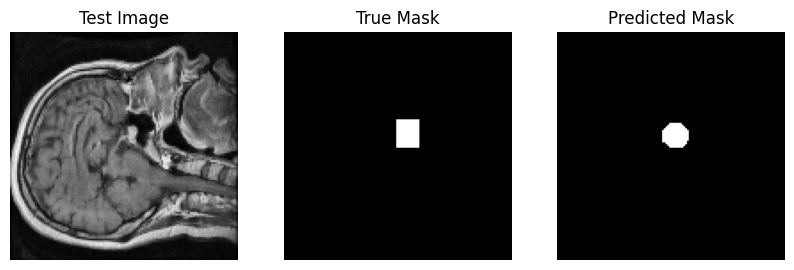

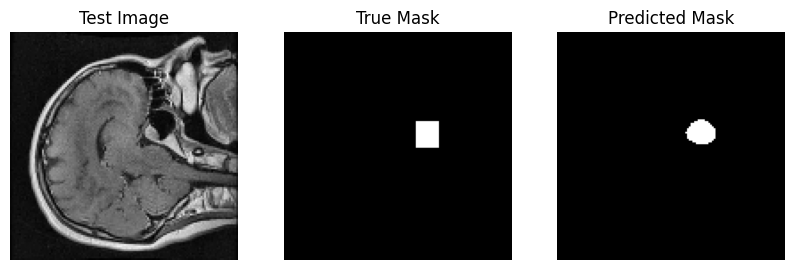

In [ ]:
plot_masked_images(FCNpredicted_masks)

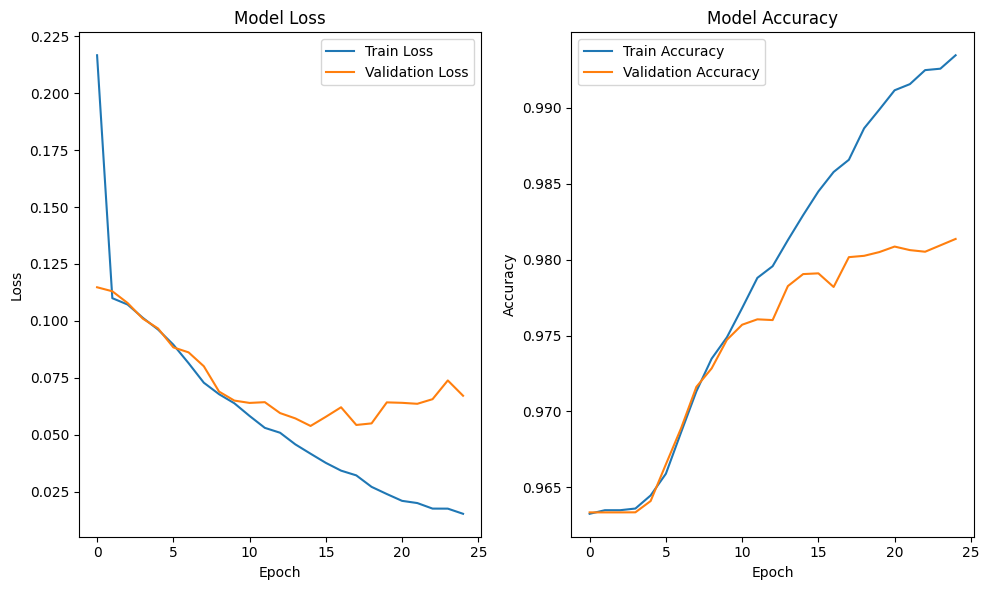

In [ ]:
plot_accuracy_loss_graph(FCNhistory)

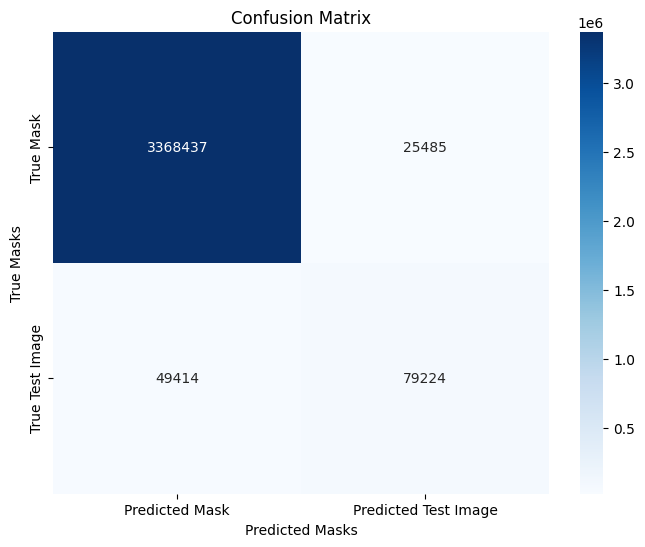

Precision: 0.7566111795547661
Recall: 0.615867784014055
F1 Score: 0.6790


In [ ]:
calculate_evaluation_matrix(FCNpredicted_masks)